## Preliminaries

### Import statements

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

### Global values

In [2]:
data_dir = "data"
plot_dir = "plot"

### Load tokens

In [3]:
token_file = os.path.join(data_dir, "tokens.tsv")
tokens = pd.read_csv(token_file, delimiter="\t", dtype=str)

### Select most frequent lemmas

In [4]:
# corpus-wide count for all non-punctuation lemmas, from most frequent to least
corpus_lemma_count = tokens["lemma"].value_counts()

# a list of the top lemmas
top_lemmas = corpus_lemma_count.head(100).index

# show results
display(corpus_lemma_count.loc[top_lemmas])

lemma
δέ        21339
καί       13671
ὁ          9589
τε         5574
ἐγώ        3783
          ...  
πέλω        530
τίθημι      530
ἄγω         525
σύν         520
βαίνω       519
Name: count, Length: 100, dtype: int64

### Labels

Label each token by author (= work title for now) and by speech/narrative (what do we call this?)

In [12]:
# Narratological groups
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
nara_group_ids = pd.Series("oth", index=tokens.index)
nara_group_ids[nr_mask] = "nar"
nara_group_ids[sp_mask] = "spk"

# Authorship groups
auth_group_ids = tokens["work"].str.slice(0,4)

# Combined two-factor group
group_ids = auth_group_ids + "-" + nara_group_ids

## Authorship

### Define samples

In [6]:
# sample labels are just work title + book number
tokens["sample_id"] = (tokens["work"] + " " + tokens["pref"].fillna("")).str.strip()

### Tokens per sample

Distribution of book lengths in tokens

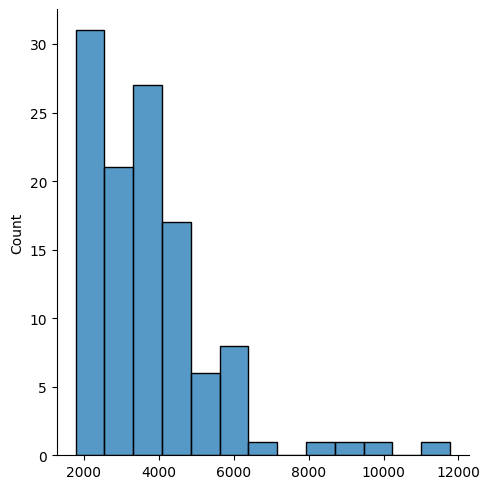

In [7]:
tokens_per_sample = tokens.groupby("sample_id").size()
sns.displot(tokens_per_sample)

### Generate feature vectors by book

In [8]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(tokens_per_sample, axis=0) * 1000

display(samples)

lemma,Διόνυσος,αἱρέω,αὐτός,βάλλω,βαίνω,γάρ,γαῖα,γε,δέ,δή,...,ἵστημι,ὀδυσσεύς,ὁ,ὄφρα,ὅδε,ὅς,ὅσος,ὅτε,ὑπό,ὡς
sample_id,,,,,,,,,,,,,,,,,,,,,
Argonautica 1,0.111595,1.339136,7.365249,1.450731,2.008704,6.137708,2.566678,1.673920,52.895882,4.240598,...,0.669568,0.000000,29.126214,2.231894,1.785515,7.030465,2.343488,2.678273,2.901462,7.142060
Argonautica 2,0.000000,1.412263,8.002825,1.647640,0.941509,6.708250,3.883724,1.412263,54.725197,5.295987,...,1.059197,0.000000,29.422149,0.706132,3.177592,6.590561,2.706838,2.471461,3.766035,7.179004
Argonautica 3,0.000000,1.564619,10.013560,1.251695,1.251695,5.006780,2.086158,2.503390,57.369354,4.172317,...,0.625848,0.000000,27.850214,1.356003,3.755085,5.736935,1.668927,2.712006,3.233545,9.492020
Argonautica 4,0.084926,1.273885,5.859873,2.208068,1.358811,6.539278,3.397028,1.358811,52.314225,5.265393,...,0.339703,0.000000,26.581741,1.953291,3.397028,8.067941,1.868365,2.717622,2.802548,6.878981
Dionysiaca 1,0.619195,0.000000,2.476780,0.619195,0.928793,3.715170,1.547988,0.928793,40.557276,0.309598,...,1.547988,0.000000,5.263158,1.857585,0.309598,0.928793,0.309598,1.857585,2.167183,4.953560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Posthomerica 6,0.000000,1.330082,4.655287,2.660164,0.886721,6.650410,1.995123,2.438484,62.735535,3.990246,...,0.221680,0.443361,27.931722,0.443361,0.443361,7.758812,1.995123,2.216803,4.655287,10.640656
Posthomerica 7,0.000000,1.383126,5.532503,2.371073,1.185536,6.322861,1.580715,2.173484,54.929856,2.568662,...,0.197589,1.383126,22.920371,0.790358,0.197589,7.508398,1.975894,4.544556,5.730093,12.250543
Posthomerica 8,0.000000,0.884434,2.653302,3.537736,0.000000,8.254717,3.242925,3.832547,65.742925,2.063679,...,0.884434,0.294811,22.995283,0.294811,0.589623,9.139151,1.179245,2.358491,4.716981,11.792453


### Dimensionality reduction

In [9]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

## Author signal
### plot individual books

This is the plot that I might start with, showing how the different books cluster themselves according to author/work based on the most frequent words.


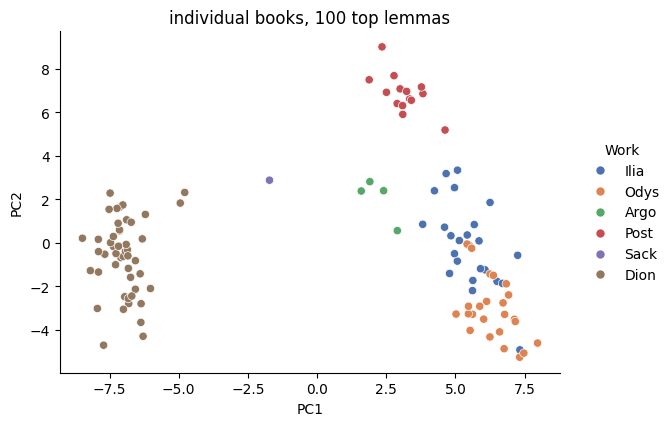

In [10]:
# Labels for legend: take first 4 chars of index (e.g. "Iliad" -> "Ilia")
short_label = samples.index.str.slice(0,4)

# Custom order for labels in the legend (top to bottom)
label_order = ["Ilia", "Odys", "Argo", "Post", "Sack", "Dion"]

# Plot using Seaborn
g = sns.relplot(data=pca,
    x = "PC1",
    y = "PC2",
    hue = short_label,        # color points by work
    hue_order = label_order,
    palette = "deep",         # seaborn color palette; try "muted", "bright", "colorblind", etc.
)

# Figure dimensions in inches (width, height)
g.figure.set_size_inches(7, 4)

# Set figure title
g.ax.set_title(f"individual books, {len(samples.columns)} top lemmas")

# Set legend heading
g._legend.set_title("Work")

# Export figure as png file
g.savefig(os.path.join(plot_dir, "auth_PCA_by_book.png"),
    # dpi=300,              # uncomment for higher resolution (default 100)
    # bbox_inches="tight",  # uncomment to trim whitespace around figure
)

plt.show()

## Speech vs. Narrative

This part shows the speech/narrative signal by averaging out authorship. We randomly sample 1000 tokens at a time from the corpus as a whole, according only to whether they are narrative or speech.

### Create new samples

In [13]:
# create samples
sample_size = 1000
for group in nara_group_ids.unique():
    n_toks = sum(nara_group_ids==group)
    tokens.loc[nara_group_ids==group, "sample_id"] = np.random.permutation(n_toks) // sample_size
tokens["sample_id"] = nara_group_ids + "-" + tokens["sample_id"].map(str)

### Tokens per sample

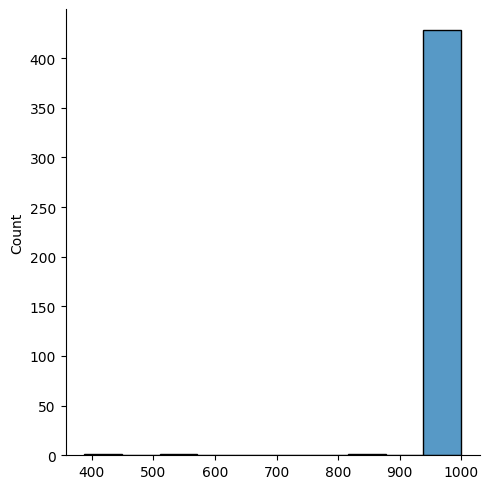

In [14]:
tokens_per_sample = tokens.groupby("sample_id").size()
sns.displot(tokens_per_sample)

### Calculate feature vectors for each sample

As in the author signal plot above, we're using the same top 1000 words.

In [15]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(tokens_per_sample, axis=0) * 1000

display(samples)

lemma,Διόνυσος,αἱρέω,αὐτός,βάλλω,βαίνω,γάρ,γαῖα,γε,δέ,δή,...,ἵστημι,ὀδυσσεύς,ὁ,ὄφρα,ὅδε,ὅς,ὅσος,ὅτε,ὑπό,ὡς
sample_id,,,,,,,,,,,,,,,,,,,,,
nar-0,2.0,2.0,3.0,1.0,1.0,3.0,2.0,0.0,57.0,3.0,...,0.0,1.0,28.0,1.0,0.0,8.0,0.0,5.0,2.0,12.0
nar-1,1.0,0.0,4.0,1.0,2.0,5.0,5.0,2.0,65.0,2.0,...,2.0,1.0,30.0,1.0,0.0,5.0,0.0,2.0,5.0,3.0
nar-10,1.0,1.0,3.0,0.0,2.0,1.0,0.0,0.0,75.0,2.0,...,0.0,3.0,31.0,1.0,0.0,6.0,1.0,3.0,0.0,10.0
nar-100,2.0,1.0,1.0,1.0,1.0,3.0,3.0,0.0,60.0,1.0,...,0.0,1.0,17.0,0.0,0.0,4.0,1.0,3.0,3.0,10.0
nar-101,4.0,2.0,4.0,3.0,0.0,1.0,1.0,1.0,52.0,0.0,...,3.0,1.0,29.0,0.0,0.0,9.0,0.0,3.0,4.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
spk-95,0.0,0.0,8.0,1.0,0.0,13.0,2.0,2.0,29.0,6.0,...,1.0,1.0,8.0,2.0,2.0,11.0,2.0,4.0,1.0,4.0
spk-96,2.0,0.0,5.0,0.0,1.0,6.0,5.0,2.0,34.0,4.0,...,2.0,2.0,12.0,3.0,1.0,10.0,0.0,4.0,3.0,7.0
spk-97,1.0,0.0,3.0,0.0,1.0,8.0,1.0,10.0,31.0,3.0,...,2.0,2.0,11.0,2.0,2.0,4.0,4.0,5.0,5.0,5.0


### Dimensionality reduction

In [16]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

### Plot

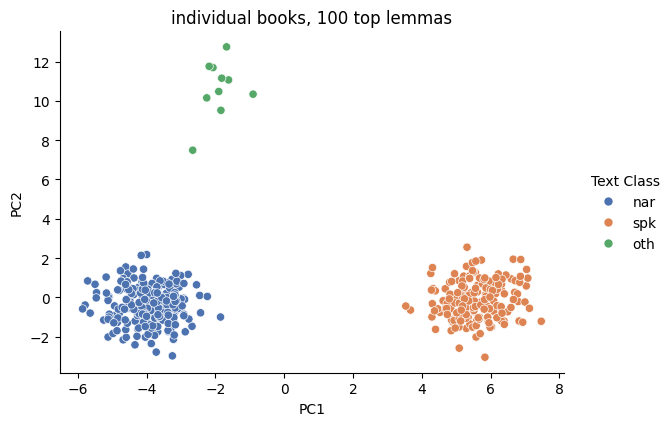

In [17]:
# Labels for legend: take first 3 chars of index
short_label = samples.index.str.slice(0,3)

# Custom order for labels in the legend (top to bottom)
label_order = ["nar", "spk", "oth"]

# Plot using Seaborn
g = sns.relplot(data=pca,
    x = "PC1",
    y = "PC2",
    hue = short_label,        # color points by work
    hue_order = label_order,
    palette = "deep",         # seaborn color palette; try "muted", "bright", "colorblind", etc.
)

# Figure dimensions in inches (width, height)
g.figure.set_size_inches(7, 4)

# Set figure title
g.ax.set_title(f"individual books, {len(samples.columns)} top lemmas")

# Set legend heading
g._legend.set_title("Text Class")

# Export figure as png file
g.savefig(os.path.join(plot_dir, "spk-nar_PCA_by_book.png"),
    # dpi=300,              # uncomment for higher resolution (default 100)
    # bbox_inches="tight",  # uncomment to trim whitespace around figure
)

plt.show()

## Speech-like words per author

In [18]:
# calculate frequencies
freq = pd.crosstab(group_ids, tokens["lemma"], normalize="index") * 1000

# remove apologue
freq = freq.loc[~(freq.index=="Odys-oth"), freq.all(axis=0)]

# calculate z-scores
scaled = freq.apply(zscore, axis=1)

# take difference between spk and nar for each author
mask = scaled.index.str.endswith("spk")
masked_names = scaled[mask].index.str.slice(0,4)
assert masked_names.equals(scaled[~mask].index.str.slice(0,4))

diff_scaled = scaled[mask].reset_index(drop=True) - scaled[~mask].reset_index(drop=True)
diff_scaled.index = masked_names
display(diff_scaled)

lemma,αἱρέω,αἷμα,αὐτίκα,αὐτός,βάλλω,βουλή,γάρ,γέρων,γίγνομαι,γαῖα,...,ἱερός,ἵππος,ἵστημι,ὀλίγος,ὁ,ὁπότε,ὅπως,ὅς,ὑπό,ὡς
row_0,,,,,,,,,,,,,,,,,,,,,
Argo,-0.189866,-0.238651,-0.272370,0.732992,-0.340287,-0.149211,0.781777,-0.229086,-0.137254,0.121022,...,-0.164277,-0.256109,-0.300111,-0.223585,-1.038100,-0.232673,-0.212106,0.246095,-0.406529,-0.627257
Dion,-0.193053,0.049504,-0.116197,0.431055,-0.127443,-0.125396,0.909403,-0.149996,0.175263,-0.128749,...,-0.120618,-0.101716,-0.157830,-0.099223,-0.595968,-0.119965,-0.019726,-0.061388,-0.258069,-0.241243
Ilia,-0.214463,-0.297247,-0.294116,0.167345,-0.421908,-0.190282,1.029260,-0.187839,-0.110052,-0.212243,...,-0.215775,-0.316674,-0.493921,-0.223591,-1.964175,-0.175982,-0.205560,0.913638,-0.380782,-1.031868
Odys,-0.420665,-0.266131,-0.331021,0.309684,-0.321684,-0.206748,1.134697,-0.203783,-0.053860,0.043752,...,-0.314171,-0.290819,-0.518147,-0.253452,-2.316576,-0.166448,-0.191169,1.010619,-0.345704,-0.931806
Post,-0.282601,-0.341450,-0.182246,0.291747,-0.429160,-0.092098,1.619297,-0.088530,-0.031940,-0.229083,...,-0.220184,-0.295474,-0.278310,-0.209976,-2.152735,-0.142999,-0.187756,0.243780,-0.269328,-0.663750
Sack,0.094484,-0.456833,-0.275562,0.305771,-0.139609,-0.366198,1.234637,-0.222740,0.237941,-0.222740,...,-0.184927,0.554872,-0.275562,-0.094291,-3.100561,-0.230245,-0.184927,0.011352,-0.253050,-0.245546


In [21]:
def show_top_lemmas_per_work(n=10, show_scores=False):
    '''Generate a table of top speech/narrative lemmas'''
    
    works = ["Ilia", "Odys", "Argo", "Post", "Sack", "Dion"]

    if show_scores:
        return pd.DataFrame(
            {work: [f"{lem} ({val:.2f})"
            for lem, val in diff_scaled.loc[work].sort_values(ascending=False).head(top_n).items()]
                 for work in works},
            index=range(1, top_n + 1)
        )
    else:
        return pd.DataFrame(
            {work: diff_scaled.loc[work].sort_values(ascending=False).head(top_n).index
                 for work in works},
            index=range(1, top_n + 1)
        )

show_top_lemmas_per_work(show_scores=True)

,Ilia,Odys,Argo,Post,Sack,Dion
1,ἐγώ (3.72),ἐγώ (3.78),ἐγώ (3.83),ἐγώ (4.29),σύ (3.82),σύ (3.58)
2,σύ (3.08),σύ (3.06),σύ (2.50),σύ (3.16),ἐγώ (3.21),ἐγώ (2.60)
3,καί (2.35),καί (2.39),ἄν (1.64),καί (2.36),καί (2.22),οὐ (2.36)
4,εἰμί (1.81),τίς (1.84),καί (1.53),εἰμί (1.83),γάρ (1.23),εἰ (1.02)
5,ἄν (1.64),εἰμί (1.84),εἰ (1.51),γάρ (1.62),εἰ (1.09),τίς (0.92)
6,τίς (1.30),οὐ (1.48),τίς (1.30),ἀλλά (1.51),ἀλλά (1.05),γάρ (0.91)
7,οὐ (1.26),ἄν (1.34),εἰμί (1.26),νῦν (1.48),ἔτι (0.95),ἀλλά (0.74)
8,ἀλλά (1.19),ἀλλά (1.29),οὐ (0.98),οὐ (1.46),τίς (0.74),αὐτός (0.43)
9,νῦν (1.10),γάρ (1.13),νῦν (0.87),τίς (1.03),οὐδέ (0.65),ζεύς (0.41)
10,γάρ (1.03),τε (1.06),ἀλλά (0.79),εἰ (0.53),ἐπί (0.60),ἤ (0.30)
